<a href="https://colab.research.google.com/github/KarlaMichelleSorianoSanhez/Simulacion-I/blob/main/Distribuci%C3%B3n_de_Poisson_(simulaci%C3%B3n).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GENERACIÓN DE UNA VARIABLE ALEATORIA DE UNA VARIABLE ALEATORIA POISSON


##INTRODUCCIÓN

La distribución de Poisson es una distibución de probabilidad discreta utilizada para modelar el número de veces que ocurre un evento dentro de un intervalo fijo de tiempo, espacio o cualquier otra unidad de medida.  

Esta distribución se utiliza cuando:
- Los eventos ocurren de manera aleatoria.
- Los eventos son independientes entre sí.
- Existe una tasa promedio constante de ocurrencia.

Las distribución Pisson tiene  aplicaciones importantes en simualción y probabilidad debido a que permite modelar fenómenos relacionados con conteos de eventos.


### APLICACIONES

- Número de llamadas telefónicas que llegan a una central.
- Número de clientes que llegan a una tienda.
- Cantidad de accidentes en una carretera.
- Número de fallas de un sistema.
- Emisión de partículas radiactivas.
- Llegadas de paquetes en una red.


## DEFINICIÓN

Si una variable aleatoria $X$ tiene distribución Poisson con parámetro $λ$, entonces su función de probabilidad está dada por:

$$
P(X=i)=e^{-λ}\frac{λ ^i}{i!},
\qquad i=0,1,2,\ldots
$$

donde:

- $X$: número de eventos observados.
- $λ$ : número promedio de eventos esperados (taza de ocurrrencia).
- $i$: número de ocurrencias.
- $e$: constante de Euler

Además una propiedad importante de esta distribución es que:


$$
E(X)=λ
$$

y

$$
Var(X)=λ
$$

es decir, la media y la varianza son iguales.


Si una variable aleatoria $X$ tiene distribución Poisson con parámetro $λ$, entonces su función de probabilidad está dada por:


## RELACIÓN RECURSIVA


Para generar una variable aleaotira Poisson utilizaremos la siguiente identidad:


$$
p_{i+1}=\frac{\lambda}{i+1}p_i
$$


Esta relación permite calcular las probabilidades sucesivas sin necesidad de calcular factoriales repetidamente.


**Demostración**


Patimos d ela función de probabilidad Poisson:


$$
p_i=P(X=i)=e^{-\lambda}\frac{\lambda^i}{i!}
$$

Ahora calculamos:

$$
p_{i+1}=e^{-\lambda}\frac{\lambda^{i+1}}{(i+1)!}
$$

Como

$$
(i+1)!=(i+1)i!
$$

entonces

$$
p_{i+1}=e^{-\lambda}\frac{\lambda^{i+1}}{(i+1)i!}
$$

Reacomodando términos

$$
p_{i+1}=
\frac{\lambda}{i+1}
\left(
e^{-\lambda}\frac{\lambda^i}{i!}
\right)
$$

pero

$$
e^{-\lambda}\frac{\lambda^i}{i!}=p_i
$$

por lo tanto

$$
p_{i+1}=\frac{\lambda}{i+1}p_i
$$

Esta identidad será utilizada para implementar el algoritmo de simulación.

## MÉTODO DE LA TRANSFORMADA INVERSA


Para generar una variable aletoria Poisson utilizaremos el método de la transformada inversa.

La idea principal consiste en:

1. Generar un número uniforme:

$$
U \sim U(0,1)
$$

2. Construir las probababilidades acumuladas de la distribución de Poisson.

3. Determinar el valor de $X$ comparando el número uniforme con dichas acumuladas


De esta manera se obtiene el valor de la variable aleatoria simulada.


## Pseudocódigo

El procedimiento utilizado para generar una variable aleatoria Poisson es el siguiente:


### Repetir:

1. Generar un número uniforme:

$$
R \sim U(0,1)
$$

2. Inicializar:

$$
i=0
$$

$$
p=e^{-\lambda}
$$

$$
F=p
$$


donde:

- $p$ representa la probabilidad actual.
- $F$ representa la probabilidad acumulada.

3. Si:

$$
R<F
$$

hacer:

$$
X=i
$$

y terminar el algoritmo.

4. En otro caso actualizar:

y terminar el algoritmo.

4. En otro caso actualizar:

$$
p=\frac{\lambda p}{i+1}
$$

$$
F=F+p
$$

$$
i=i+1
$$

5. Regresar al paso 3 hasta encontrar el valor correspondiente de la variable aleatoria.

In [18]:
# importamos las librerias

import numpy as np
import random as r
import matplotlib.pyplot as plt
from scipy.special import factorial


# Función de Probabilidad Teórica

A continuación se define la función de probabilidad teórica de la distribución Poisson, la cual se utilizará posteriormente para comparar los resultados obtenidos mediante simulación.

In [19]:
# Función de probabilidad Poisson

def poisson_teorica(lamda, i):
        return np.exp(-lamda)*(lamda**i)/factorial(i)

# Implementación del Algoritmo

A continuación se implementa el algoritmo visto en clase para generar variables aleatorias con distribución Poisson utilizando el método de la transformada inversa.

El algoritmo sigue directamente el pseudocódigo mostrado en el pizarrón.

In [20]:
# Función para generar variables Poisson

def simular_poisson(lamda, i, n):
  #lista donde se almacenarán los valores simulados
  muestra =[]

  #repetir n veces
  for j in range (n):

    #generar número uniforme
    R= r.random ()

    #inicializar variables
    p=np.exp(-lamda)

    F_acum =p

    #verificar primer intervalo

    if R<F_acum:
      x=0
      muestra.append(x)

    else:
      #construir probabilidades acumuladas

      for t in range(1, i+1):

        # Relación recursiva
        p = lamda*p/t

        # Actualizar acumulada
        F_acum = F_acum + p

        # Verificar intervalo
        if R < F_acum:
          x=t
          muestra.append(x)

          break

  # Regresar lista de valores simulados
  return muestra

# Parámetros de Simulación

Se definen los parámetros que se utilizarán para realizar la simulación:

- $n$: número de simulaciones.
- $\lambda$: media de la distribución Poisson.
- $i$: número máximo de valores considerados.

In [21]:
# Parámetros de simulación

n = 10000
lamda = 10
i = 100

# Generar simulación
P = simular_poisson(lamda, i, n)

# Comparación Gráfica

A continuación se compara la distribución teórica Poisson contra los resultados obtenidos mediante simulación.

Para normalizar el histograma se utiliza:

```python
density = True

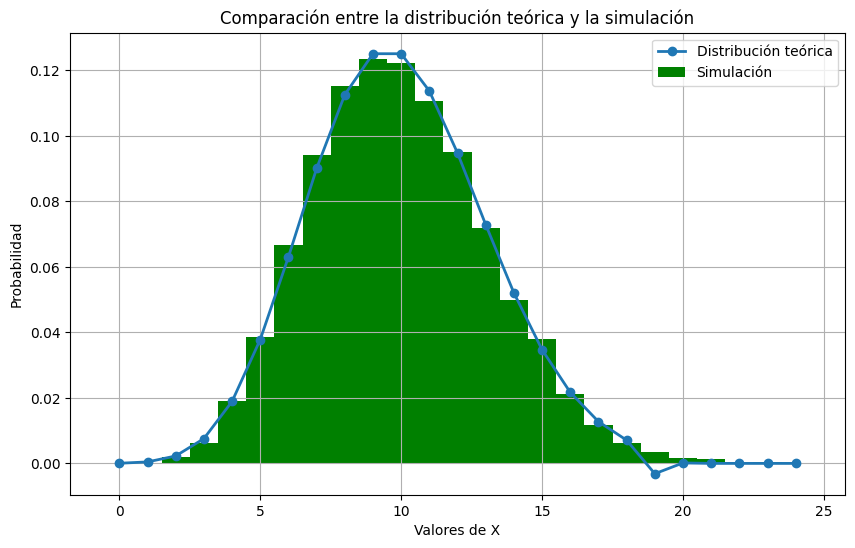

In [23]:
# Comparación gráfica
muestra = simular_poisson(lamda, i, n)

#valores discretos para la distribución teórica
x=np.arange(0, max(muestra)+1)

# Probabilidades teóricas
y=poisson_teorica(lamda, x)

# crear figura
plt.figure(figsize=(10,6))

# Distribución teórica
plt.plot(x,y, marker="o", linewidth=2, label="Distribución teórica")


# Definir bins discretos
bins = []

for k in range(max(muestra)+2):
    bins.append(k - 0.5)


# Histograma de simulación
plt.hist(muestra, color="green",bins = bins, density = True, label = "Simulación" )

# Detalles de la gráfica
plt.title("Comparación entre la distribución teórica y la simulación")
plt.xlabel("Valores de X")
plt.ylabel("Probabilidad")

plt.legend()

plt.grid()

plt.show()


# Conclusiones

En esta práctica se implementó un algoritmo para generar variables aleatorias con distribución Poisson utilizando el método de la transformada inversa.

La relación recursiva:

$$
p_{i+1}=\frac{\lambda}{i+1}p_i
$$

permitió calcular las probabilidades sucesivas de manera eficiente, evitando calcular factoriales repetidamente.

A partir de la simulación realizada se observó que el histograma obtenido es muy cercano a la distribución teórica Poisson, lo cual indica que el algoritmo implementado reproduce correctamente el comportamiento probabilístico esperado.

Finalmente, la distribución Poisson es una herramienta muy importante en simulación debido a que permite modelar fenómenos asociados al conteo de eventos aleatorios.